# 每个区域单车出流和入流关系分布
对之前通过ArcGIS划分后的区域进行区域流量的统计，统计每个区域作为出发地的单车记录作为该区域的出流（不包含终点在同一区内的数据），区域作为终止地的单车记录为该区域的入流（不包含起始点在同一区域的数据）。

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import copy
import time
import sys
import math
import datetime
from math import radians, cos, sin, asin, sqrt
from matplotlib.colors import LogNorm
from io import StringIO
from sklearn import linear_model
#import tensorflow as tf
from scipy import optimize
import math
#from scipy.optimize import curve_fit
plt.rcParams["font.sans-serif"]=["SimHei"] #用来正常显示中文标签
plt.rcParams["axes.unicode_minus"]=False #用来正常显示负号

In [2]:
from math import sin, asin, cos, radians, fabs, sqrt
EARTH_RADIUS=6371 
def hav(theta):
    s = sin(theta / 2)
    return s * s
def get_distance_hav(lat0, lng0, lat1, lng1):    #lat纬度
    lat0 = radians(lat0)
    lat1 = radians(lat1)
    lng0 = radians(lng0)
    lng1 = radians(lng1)
    dlng = fabs(lng0 - lng1)
    dlat = fabs(lat0 - lat1)
    h = hav(dlat) + cos(lat0) * cos(lat1) * hav(dlng)
    distance = 2 * EARTH_RADIUS * asin(sqrt(h))
    return distance

In [3]:
df=pd.read_csv('df.csv')   #筛选后的单车数据
#df

In [4]:
sid=(np.load("500m起始区域id(bj).npy")).tolist()
sid1=pd.Series(sid)
eid=(np.load("500m终点区域id(bj).npy")).tolist()
eid1=pd.Series(eid)

In [5]:
df["sid"]=sid1   #起始id
df["eid"]=eid1   #终点id

In [6]:
s_eid=[]
for i in range(0,len(df)):
    c=[]
    a=df.iloc[i]["sid"]
    b=df.iloc[i]["eid"]
    c.append(a)
    c.append(b)
    s_eid.append(c)

In [7]:
for i in range(0,len(s_eid)):
    hr=s_eid[i]
    s_eid[i]=str(hr)

In [8]:
s_eid1=pd.Series(s_eid)
s_eid1

0             [941, 9347]
1          [50459, 47949]
2           [4148, 58023]
3           [9126, 19416]
4           [6347, 23909]
                ...      
3094262     [7521, 22824]
3094263    [10753, 54699]
3094264    [14429, 14445]
3094265     [3574, 11820]
3094266    [57346, 62927]
Length: 3094267, dtype: object

In [9]:
df["s_eid"]=s_eid1

In [10]:
e_sid=[]
for i in range(0,len(df)):
    c=[]
    a=df.iloc[i]["sid"]
    b=df.iloc[i]["eid"]
    c.append(b)
    c.append(a)
    e_sid.append(c)

In [11]:
for i in range(0,len(e_sid)):
    hr=e_sid[i]
    e_sid[i]=str(hr)

In [12]:
e_sid1=pd.Series(e_sid)
e_sid1

0             [9347, 941]
1          [47949, 50459]
2           [58023, 4148]
3           [19416, 9126]
4           [23909, 6347]
                ...      
3094262     [22824, 7521]
3094263    [54699, 10753]
3094264    [14445, 14429]
3094265     [11820, 3574]
3094266    [62927, 57346]
Length: 3094267, dtype: object

In [13]:
df["e_sid"]=e_sid1

In [6]:
df1_1=df[df["sid"]!=-1]

In [7]:
df1_2=df1_1[df1_1["eid"]!=-1]

In [8]:
df2 = pd.read_csv("500popdata_bj.csv")      #包含区域人口数据
df2

,OBJECTID,Id,Shape_Length,Shape_Area,x,y,OBJECTID_1,Id_1,COUNT,AREA,SUM
0,1,1,429.039265,5038.229607,117.287788,40.660110,1,1,1,6.944440e-07,0.176861
1,2,2,2000.000000,250000.000000,117.219658,40.637150,2,2,39,2.708330e-05,6.566072
2,3,3,2000.000000,250000.000000,116.406105,40.115814,3,3,36,2.500000e-05,3066.989456
3,4,4,2000.000000,250000.000000,116.558075,39.670311,4,4,39,2.708330e-05,294.448074
4,5,5,2000.000000,250000.000000,116.881973,40.199058,5,5,36,2.500000e-05,99.206474
...,...,...,...,...,...,...,...,...,...,...,...
66611,66612,66612,2000.000000,250000.000000,115.868393,39.889046,66289,66612,35,2.430560e-05,10.857436
66612,66613,66613,2000.000000,250000.000000,115.907280,39.747780,66290,66613,40,2.777780e-05,74.296542
66613,66614,66614,2000.000000,250000.000000,116.470535,39.798256,66291,66614,36,2.500000e-05,1435.749268
66614,66615,66615,2000.000000,250000.000000,115.858429,39.578114,66292,66615,36,2.500000e-05,161.408242


In [10]:
id_=(df2["Id"]).tolist()
cx=(df2["x"]).tolist()
cy=(df2["y"]).tolist()
pop=(df2["SUM"]).tolist()

In [11]:
dic1=dict(zip(id_,cx)) #整体区域的中心经纬度坐标
dic2=dict(zip(id_,cy))
dic3=dict(zip(id_,pop))

In [9]:
id_=(df2["Id"]).tolist()
sum_=(df2["SUM"]).tolist()

In [18]:
pop_di=[]
for i in range(0,len(id_)):
    c=[]
    a=id_[i]
    b=sum_[i]
    c.append(a)
    c.append(b)
    pop_di.append(c)

In [19]:
pdict=dict(pop_di)    #区域：区域人口字典
pdict

{1: 0.176860884,
 2: 6.566072151,
 3: 3066.989456,
 4: 294.44807389999994,
 5: 99.20647359,
 6: 561.376092,
 7: 11.25063387,
 8: 9.369686231000001,
 9: 595.0686965,
 10: 202.3246124,
 11: 7.680678338,
 12: 692.0158176,
 13: 5.351240046,
 14: 2423.547534,
 15: 3.446926907,
 16: 1472.146921,
 17: 192.7489436,
 18: 5.765258983,
 19: 14.823255900000001,
 20: 3.7699324639999996,
 21: 1.669728834,
 22: 107.7345262,
 23: 135.30022730000002,
 24: 2621.897984,
 25: 5.215484999,
 26: 96.94946027,
 27: 13.162939999999999,
 28: 144.5100641,
 29: 2.284390621,
 30: 14.43347067,
 31: 7.430081412000001,
 32: 8.081270963,
 33: 8561.126129,
 34: 114.02728799999998,
 35: 80.18139869,
 36: 181.73392030000002,
 37: 42.84086931,
 38: 1.8918089790000001,
 39: 4955.650162,
 40: 155.84125490000002,
 41: 70.98434758,
 42: 1044.790845,
 43: 241.90002349999997,
 44: 15.80234748,
 45: 38.6877948,
 46: 4.572195195,
 47: 9.794971839,
 48: 242.94633149999999,
 49: 95.93226552,
 50: 6919.403572,
 51: 6.866635561,
 52:

In [12]:
df_io=df1_2[df1_2["sid"]!=df1_2["eid"]]   #不包含区域自流量的数据
df_io

,orderid,userid,bikeid,biketype,starttime,geohashed_start_loc,geohashed_end_loc,start_x,start_y,end_x,end_y,BJ,Travel_time(s),speed,sid,eid
0,1893973,451147,210617,2,2017-05-14 22:16:50,wx4snhx,wx4snhj,116.289597,40.103531,116.286850,40.100784,1,141,2.727397,941,9347
1,4657992,1061133,465394,1,2017-05-14 22:16:52,wx4dr59,wx4dquz,116.325302,39.790421,116.322556,39.797287,1,265,3.013957,50459,47949
2,2965085,549189,310572,1,2017-05-14 22:16:51,wx4fgur,wx4fu5n,116.542282,39.882431,116.551895,39.875565,1,625,1.792963,4148,58023
3,3936364,467449,403224,1,2017-05-14 22:16:50,wx4g27p,wx4g266,116.388474,39.963455,116.381607,39.959335,1,250,2.972972,9126,19416
4,5163705,917620,509044,1,2017-05-14 22:16:53,wx4gd2e,wx4g6pw,116.470871,39.993668,116.464005,39.988174,1,231,3.661382,6347,23909
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3094262,308143,683030,42881,1,2017-05-23 06:20:55,wx4gjs9,wx4gjs0,116.610947,39.927750,116.609573,39.925003,1,103,3.176235,7521,22824
3094263,1886236,394183,209895,2,2017-05-23 06:20:57,wx4fd57,wx4fd4d,116.459885,39.832993,116.458511,39.828873,1,560,0.844479,10753,54699
3094264,2162814,878844,235870,2,2017-05-23 06:20:56,wx4fbyv,wx4g08r,116.407700,39.896164,116.399460,39.904404,1,385,2.999509,14429,14445
3094265,3702730,104540,380669,1,2017-05-23 06:20:56,wx4u11d,wx4u10c,116.414566,40.087051,116.413193,40.082932,1,123,3.842861,3574,11820


In [13]:
s_id=(df1_2["sid"]).tolist()
e_id=(df1_2["eid"]).tolist()

In [14]:
s_eid=[]     #所有的区域id
s_eid.extend(s_id)
s_eid.extend(e_id)

In [15]:
seid1=pd.Series(s_eid)

In [16]:
un_id=seid1.value_counts()   #所有区域id   有的没有进或出流量

In [17]:
un_id1=(un_id.index).tolist()

In [18]:
len(un_id1)

14093

In [19]:
outtr=[]     #某个区域的出入流量人口数目
intr=[]
center_x=[]
center_y=[]
#popnu=[]
for i in range(0,len(un_id1)):
    z=un_id1[i]   #区域id
    dd=df_io[df_io["sid"]==z]  
    l1=len(dd)   #区域z的出流量
    outtr.append(l1)
    dd1=df_io[df_io["eid"]==z]
    l2=len(dd1)   #区域z的入流量
    intr.append(l2)
    #popu=pdict[z]   #区域人口
    
    #popnu.append(popu)
    center_x.append(dic1[z])
    center_y.append(dic2[z])

In [21]:
dataframe=pd.DataFrame(columns=['cx','cy','out','in'])
dataframe['cx']=center_x
dataframe['cy']=center_y
dataframe['out']=outtr
dataframe['in']=intr

In [22]:
#dataframe.to_csv('500m.csv')

In [27]:
outtr=[]     #某个区域的出入流量人口数目
intr=[]
popnu=[]
for i in range(0,len(un_id1)):
    z=un_id1[i]   #区域id
    dd=df_io[df_io["sid"]==z]  
    l1=len(dd)   #区域z的出流量
    outtr.append(l1)
    dd1=df_io[df_io["eid"]==z]
    l2=len(dd1)   #区域z的入流量
    intr.append(l2)
    popu=pdict[z]   #区域人口
    
    popnu.append(popu)

In [28]:
#np.save('500mouttr',outtr)
#np.save('500mintr',intr)
#np.save('500mpopnu',popnu)

In [2]:
#outtr=(np.load('500mouttr.npy')).tolist()#区域出流
#intr=(np.load('500mintr.npy')).tolist()#区域入流
#popnu=(np.load('500mpopnu.npy')).tolist()#区域人口

In [54]:
def f_1(x, A, B):
    return A * x + B
x0 =outtr
y0 =intr
A1, B1 = optimize.curve_fit(f_1, x0, y0)[0]
x1 = np.arange(0, 7482, 0.01)#30和75要对应x0的两个端点，0.01为步长
y1 = A1 * x1 + B1

In [55]:
print(A1)
print(B1)

0.9701339852460263
6.039935682742519


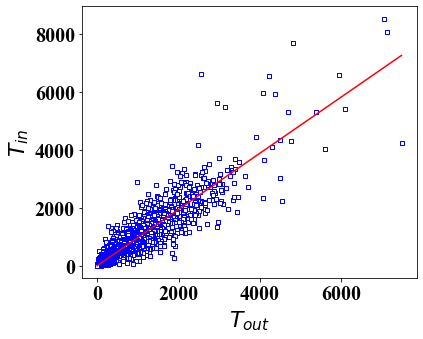

In [56]:
fig= plt.figure(figsize=(6,5))        #一个区域的出和进流量
ax = fig.add_subplot(1,1,1) 
plt.scatter(outtr,intr,marker = 's',color="w",linewidths=1,s=20,edgecolors='blue')
plt.plot(x1, y1, "red")  #y=0.9920583455398205x+1.4924510808168334
#plt.scatter(popnu,intr,marker = 's',color="w",linewidths=1,s=20,edgecolors='red',label="Tin",alpha=0.6)
#plt.plot( eavd,eloc_num, marker='.',color="red",label="in_Tij",alpha=0.1)
#plt.legend(loc="best",prop={'size':20,'family':'Times New Roman'})
#ax.set_yscale("log")
#ax.set_xscale("log")
plt.yticks(fontproperties = 'Times New Roman')
plt.xticks(fontproperties = 'Times New Roman') 
ax.set_ylabel("$T_{in}$",size=22,family='Times New Roman')  
ax.set_xlabel("$T_{out}$",size=22,family='Times New Roman')
plt.tick_params(labelsize=20)